## Problem 3 Overview

This notebook completes the ResNet-11 versus ResNet-18 experiment for CIFAR-10. It implements residual BasicBlocks from scratch, trains baseline and dropout variants, and summarizes the final comparison across ResNet depth and regularization settings.


### Mount Google Drive

This cell connects Google Drive so the longer ResNet training runs can save checkpoints and results between Colab sessions.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### Imports, Reproducibility, and Output Folders

This cell imports the required packages, sets seed 42, selects CUDA when available, and creates the Problem 3 output folders.


In [ ]:
import os
import time
import random
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, Subset, Dataset
from PIL import Image

seed = 42
batch_size = 128
learning_rate = 0.001
resnet_epochs = 50
num_classes = 10

random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

OUTPUT_DIR = Path("/content/drive/MyDrive/ECGR4106_HW1/problem3")
FIG_DIR = OUTPUT_DIR / "figures"
CKPT_DIR = OUTPUT_DIR / "checkpoints"
FIG_DIR.mkdir(parents=True, exist_ok=True)
CKPT_DIR.mkdir(parents=True, exist_ok=True)
print("Saving outputs to:", OUTPUT_DIR)

Using device: cuda
Saving outputs to: /content/drive/MyDrive/ECGR4106_HW1/problem3


### CIFAR-10 Dataset and DataLoaders

This cell loads CIFAR-10 with the same preprocessing and train-validation-test split used in Problems 1 and 2. Keeping the data pipeline fixed supports the final architecture comparison.


In [ ]:
cifar10_mean = (0.4914, 0.4822, 0.4465)
cifar10_std = (0.2470, 0.2435, 0.2616)

train_transform = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(cifar10_mean, cifar10_std),
])

eval_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(cifar10_mean, cifar10_std),
])

classes = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck",
]


class CIFAR10FromArrays(Dataset):
    def __init__(self, images, labels, transform=None):
        self.images = images
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        image = Image.fromarray(self.images[idx])
        label = int(self.labels[idx])
        if self.transform is not None:
            image = self.transform(image)
        return image, label


def load_cifar10_from_fastai_mirror():
    import tarfile
    import urllib.request

    data_root = Path("./data")
    archive_path = data_root / "fastai-cifar10.tgz"
    extracted_root = data_root / "cifar10"
    url = "https://s3.amazonaws.com/fast-ai-imageclas/cifar10.tgz"

    data_root.mkdir(parents=True, exist_ok=True)

    if not extracted_root.exists():
        print("Downloading CIFAR-10 from fast.ai mirror...")
        urllib.request.urlretrieve(url, archive_path)
        print("Extracting CIFAR-10 archive...")
        with tarfile.open(archive_path, "r:gz") as tar:
            tar.extractall(data_root)

    train_dir = extracted_root / "train"
    test_dir = extracted_root / "test"

    train_base = torchvision.datasets.ImageFolder(train_dir, transform=train_transform)
    val_base = torchvision.datasets.ImageFolder(train_dir, transform=eval_transform)
    test_dataset = torchvision.datasets.ImageFolder(test_dir, transform=eval_transform)
    print("Loaded CIFAR-10 with fast.ai mirror + PyTorch ImageFolder.")
    return train_base, val_base, test_dataset


def load_cifar10_datasets():
    try:
        print("Trying torchvision CIFAR-10 download...")
        train_base = torchvision.datasets.CIFAR10("./data", train=True, download=True, transform=train_transform)
        val_base = torchvision.datasets.CIFAR10("./data", train=True, download=False, transform=eval_transform)
        test_dataset = torchvision.datasets.CIFAR10("./data", train=False, download=True, transform=eval_transform)
        print("Loaded CIFAR-10 with torchvision.")
        return train_base, val_base, test_dataset
    except Exception as error:
        print("torchvision download failed:", repr(error))

    try:
        print("Trying tensorflow.keras CIFAR-10 loader...")
        import tensorflow as tf
        (x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()
        y_train = y_train.flatten()
        y_test = y_test.flatten()
        train_base = CIFAR10FromArrays(x_train, y_train, transform=train_transform)
        val_base = CIFAR10FromArrays(x_train, y_train, transform=eval_transform)
        test_dataset = CIFAR10FromArrays(x_test, y_test, transform=eval_transform)
        print("Loaded CIFAR-10 with tensorflow.keras arrays.")
        return train_base, val_base, test_dataset
    except Exception as error:
        print("tensorflow.keras download failed:", repr(error))

    print("Trying fast.ai public mirror...")
    return load_cifar10_from_fastai_mirror()


train_base, val_base, test_dataset = load_cifar10_datasets()

generator = torch.Generator().manual_seed(seed)
indices = torch.randperm(len(train_base), generator=generator).tolist()
train_indices = indices[:45000]
val_indices = indices[45000:]

train_dataset = Subset(train_base, train_indices)
val_dataset = Subset(val_base, val_indices)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=(device == "cuda"))
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=(device == "cuda"))
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=(device == "cuda"))

print("Training images:", len(train_dataset))
print("Validation images:", len(val_dataset))
print("Test images:", len(test_dataset))
print("Classes:", classes)

Trying torchvision CIFAR-10 download...


100%|██████████| 170M/170M [00:06<00:00, 24.9MB/s]


Loaded CIFAR-10 with torchvision.
Training images: 45000
Validation images: 5000
Test images: 10000
Classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


### Training and Plotting Helpers

This cell defines the reusable training, evaluation, checkpointing, plotting, and confusion matrix utilities for the ResNet experiments.


In [ ]:
def count_trainable_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


def train_one_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss, total_correct, total = 0.0, 0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        logits = model(images)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * images.size(0)
        total_correct += (logits.argmax(1) == labels).sum().item()
        total += labels.size(0)
    return total_loss / total, total_correct / total


@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    total_loss, total_correct, total = 0.0, 0, 0
    all_preds, all_labels = [], []
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        logits = model(images)
        loss = criterion(logits, labels)
        preds = logits.argmax(1)
        total_loss += loss.item() * images.size(0)
        total_correct += (preds == labels).sum().item()
        total += labels.size(0)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
    return total_loss / total, total_correct / total, np.array(all_preds), np.array(all_labels)


def train_model(model, run_name, epochs=50, lr=0.001):
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    best_val_acc = -1
    best_path = CKPT_DIR / f"{run_name}_best.pth"
    history = []
    start_time = time.time()

    for epoch in range(1, epochs + 1):
        epoch_start = time.time()
        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer)
        val_loss, val_acc, _, _ = evaluate(model, val_loader, criterion)
        scheduler.step()
        epoch_time = time.time() - epoch_start

        history.append({
            "epoch": epoch,
            "train_loss": train_loss,
            "train_accuracy": train_acc,
            "val_loss": val_loss,
            "val_accuracy": val_acc,
            "lr": optimizer.param_groups[0]["lr"],
            "epoch_time_sec": epoch_time,
        })

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), best_path)

        print(f"{run_name} | epoch {epoch:02d}/{epochs} | train loss {train_loss:.4f} | train acc {train_acc:.4f} | val loss {val_loss:.4f} | val acc {val_acc:.4f} | {epoch_time:.1f}s")

    total_time = time.time() - start_time
    history_df = pd.DataFrame(history)
    history_df.to_csv(OUTPUT_DIR / f"{run_name}_history.csv", index=False)

    model.load_state_dict(torch.load(best_path, map_location=device))
    test_loss, test_acc, test_preds, test_labels = evaluate(model, test_loader, criterion)

    summary = {
        "run_name": run_name,
        "epochs": epochs,
        "learning_rate": lr,
        "optimizer": "Adam",
        "scheduler": "CosineAnnealingLR",
        "batch_size": batch_size,
        "seed": seed,
        "parameter_count": count_trainable_parameters(model),
        "best_val_accuracy": float(history_df["val_accuracy"].max()),
        "test_loss": float(test_loss),
        "final_test_accuracy": float(test_acc),
        "total_training_time_sec": float(total_time),
        "mean_epoch_time_sec": float(history_df["epoch_time_sec"].mean()),
    }

    with open(OUTPUT_DIR / f"{run_name}_summary.json", "w") as f:
        json.dump(summary, f, indent=2)

    return model, history_df, {"loss": test_loss, "accuracy": test_acc, "preds": test_preds, "labels": test_labels}, summary


def plot_history(history_df, run_name):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(history_df["epoch"], history_df["train_loss"], label="Train loss")
    axes[0].plot(history_df["epoch"], history_df["val_loss"], label="Validation loss")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].set_title(f"{run_name}: Loss")
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(history_df["epoch"], history_df["train_accuracy"], label="Train accuracy")
    axes[1].plot(history_df["epoch"], history_df["val_accuracy"], label="Validation accuracy")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Accuracy")
    axes[1].set_title(f"{run_name}: Accuracy")
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    save_path = FIG_DIR / f"{run_name}_curves.png"
    plt.savefig(save_path, dpi=200, bbox_inches="tight")
    plt.show()
    print("Saved:", save_path)


def plot_confusion_matrix(labels, preds, run_name):
    matrix = np.zeros((len(classes), len(classes)), dtype=int)
    for true_label, pred_label in zip(labels, preds):
        matrix[true_label, pred_label] += 1

    fig, ax = plt.subplots(figsize=(8, 7))
    im = ax.imshow(matrix, cmap="Blues")
    ax.set_title(f"{run_name}: Confusion Matrix")
    ax.set_xlabel("Predicted label")
    ax.set_ylabel("True label")
    ax.set_xticks(np.arange(len(classes)))
    ax.set_yticks(np.arange(len(classes)))
    ax.set_xticklabels(classes, rotation=45, ha="right")
    ax.set_yticklabels(classes)

    for i in range(len(classes)):
        for j in range(len(classes)):
            color = "white" if matrix[i, j] > matrix.max() * 0.55 else "black"
            ax.text(j, i, str(matrix[i, j]), ha="center", va="center", color=color, fontsize=8)

    fig.colorbar(im, ax=ax)
    plt.tight_layout()
    save_path = FIG_DIR / f"{run_name}_confusion_matrix.png"
    plt.savefig(save_path, dpi=200, bbox_inches="tight")
    plt.show()
    print("Saved:", save_path)


def compare_histories(histories, metric, title, ylabel, filename):
    plt.figure(figsize=(8, 5))
    for run_name, history_df in histories.items():
        plt.plot(history_df["epoch"], history_df[metric], label=run_name)
    plt.xlabel("Epoch")
    plt.ylabel(ylabel)
    plt.title(title)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    save_path = FIG_DIR / filename
    plt.savefig(save_path, dpi=200, bbox_inches="tight")
    plt.show()
    print("Saved:", save_path)

### ResNet BasicBlock and Model Definitions

This cell defines the residual BasicBlock, CIFAR-style ResNet class, ResNet-11, and ResNet-18. The ImageNet 7x7 stem is replaced by a 3x3 convolution with no initial max pooling for 32x32 CIFAR-10 inputs.


In [ ]:
class BasicBlock(nn.Module):
    expansion = 1

    def __init__(self, in_channels, out_channels, stride=1):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)

        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels),
            )
        else:
            self.shortcut = nn.Identity()

    def forward(self, x):
        identity = self.shortcut(x)
        out = self.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out = out + identity
        out = self.relu(out)
        return out


class CIFARResNet(nn.Module):
    def __init__(self, block_counts, num_classes=10, dropout_p=0.0, base_channels=64):
        super().__init__()
        self.in_channels = base_channels
        self.dropout_p = dropout_p

        self.stem = nn.Sequential(
            nn.Conv2d(3, base_channels, kernel_size=3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(base_channels),
            nn.ReLU(inplace=True),
        )

        self.layer1 = self._make_layer(base_channels, block_counts[0], stride=1)
        self.layer2 = self._make_layer(base_channels * 2, block_counts[1], stride=2)
        self.layer3 = self._make_layer(base_channels * 4, block_counts[2], stride=2)
        self.layer4 = self._make_layer(base_channels * 8, block_counts[3], stride=2)

        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.dropout = nn.Dropout(p=dropout_p) if dropout_p > 0 else nn.Identity()
        self.fc = nn.Linear(base_channels * 8, num_classes)

    def _make_layer(self, out_channels, num_blocks, stride):
        strides = [stride] + [1] * (num_blocks - 1)
        layers = []
        for block_stride in strides:
            layers.append(BasicBlock(self.in_channels, out_channels, stride=block_stride))
            self.in_channels = out_channels
        return nn.Sequential(*layers)

    def forward(self, x):
        x = self.stem(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.dropout(x)
        x = self.fc(x)
        return x


def ResNet11(num_classes=10, dropout_p=0.0):
    # 1 stem conv + 5 BasicBlocks * 2 convs = 11 convolutional layers
    return CIFARResNet(block_counts=[1, 1, 1, 2], num_classes=num_classes, dropout_p=dropout_p)


def ResNet18(num_classes=10, dropout_p=0.0):
    # 1 stem conv + 8 BasicBlocks * 2 convs + 1 FC = common ResNet-18 naming
    return CIFARResNet(block_counts=[2, 2, 2, 2], num_classes=num_classes, dropout_p=dropout_p)


resnet11_test = ResNet11(num_classes=num_classes, dropout_p=0.0)
resnet18_test = ResNet18(num_classes=num_classes, dropout_p=0.0)

print("ResNet-11 parameters:", count_trainable_parameters(resnet11_test))
print("ResNet-18 parameters:", count_trainable_parameters(resnet18_test))
print(resnet18_test)

ResNet-11 parameters: 9623882
ResNet-18 parameters: 11173962
CIFARResNet(
  (stem): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
  )
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (shortcut): Identity()
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
     

### Train ResNet-11 Baseline

This cell trains ResNet-11 without dropout for 50 epochs. This provides the shallower residual baseline.


In [ ]:
resnet11_baseline = ResNet11(num_classes=num_classes, dropout_p=0.0)
resnet11_baseline, hist_r11_base, test_r11_base, summary_r11_base = train_model(
    resnet11_baseline,
    run_name="resnet11_baseline",
    epochs=resnet_epochs,
    lr=learning_rate,
)
summary_r11_base

resnet11_baseline | epoch 01/50 | train loss 1.4357 | train acc 0.4755 | val loss 1.1896 | val acc 0.5882 | 30.3s
resnet11_baseline | epoch 02/50 | train loss 0.9769 | train acc 0.6503 | val loss 1.0964 | val acc 0.6298 | 28.8s
resnet11_baseline | epoch 03/50 | train loss 0.7775 | train acc 0.7288 | val loss 0.8043 | val acc 0.7176 | 29.4s
resnet11_baseline | epoch 04/50 | train loss 0.6553 | train acc 0.7702 | val loss 0.6397 | val acc 0.7786 | 30.2s
resnet11_baseline | epoch 05/50 | train loss 0.5704 | train acc 0.8003 | val loss 0.5837 | val acc 0.7938 | 30.5s
resnet11_baseline | epoch 06/50 | train loss 0.5097 | train acc 0.8222 | val loss 0.6033 | val acc 0.8020 | 30.0s
resnet11_baseline | epoch 07/50 | train loss 0.4645 | train acc 0.8388 | val loss 0.4758 | val acc 0.8382 | 30.2s
resnet11_baseline | epoch 08/50 | train loss 0.4180 | train acc 0.8540 | val loss 0.4899 | val acc 0.8344 | 30.9s
resnet11_baseline | epoch 09/50 | train loss 0.3849 | train acc 0.8672 | val loss 0.4345

{'run_name': 'resnet11_baseline',
 'epochs': 50,
 'learning_rate': 0.001,
 'optimizer': 'Adam',
 'scheduler': 'CosineAnnealingLR',
 'batch_size': 128,
 'seed': 42,
 'parameter_count': 9623882,
 'best_val_accuracy': 0.926,
 'test_loss': 0.41346378841400144,
 'final_test_accuracy': 0.9196,
 'total_training_time_sec': 1534.9731676578522,
 'mean_epoch_time_sec': 30.639828062057497}

### Plot ResNet-11 Baseline Results

This cell creates the training curves and confusion matrix for the ResNet-11 baseline.


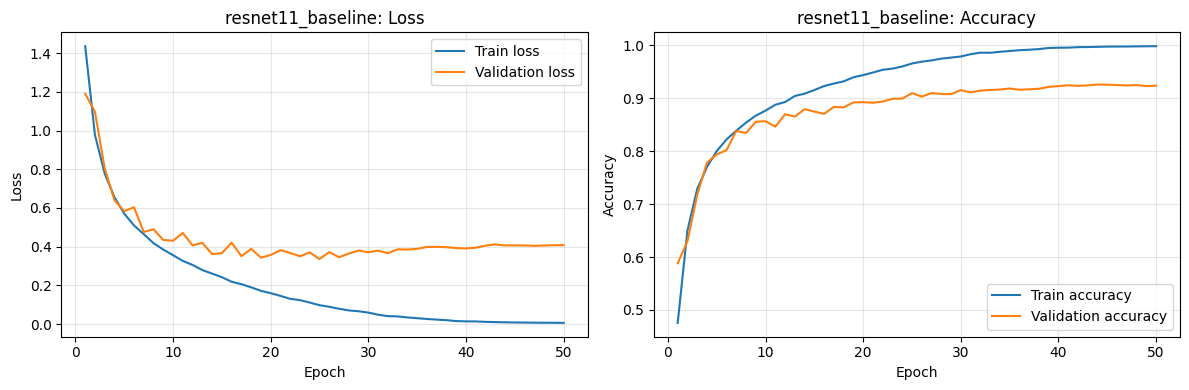

Saved: /content/drive/MyDrive/ECGR4106_HW1/problem3/figures/resnet11_baseline_curves.png


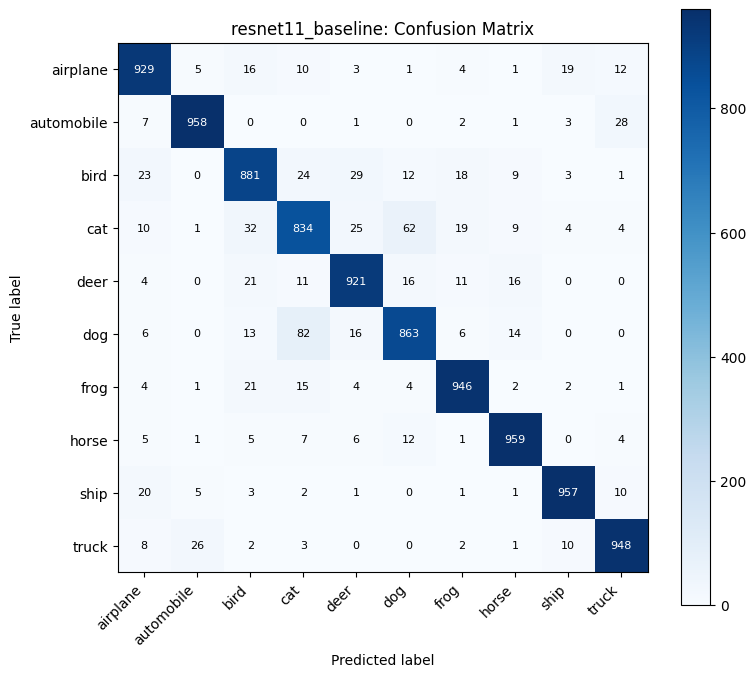

Saved: /content/drive/MyDrive/ECGR4106_HW1/problem3/figures/resnet11_baseline_confusion_matrix.png


In [ ]:
plot_history(hist_r11_base, "resnet11_baseline")
plot_confusion_matrix(test_r11_base["labels"], test_r11_base["preds"], "resnet11_baseline")

### Train ResNet-18 Baseline

This cell trains ResNet-18 without dropout for 50 epochs. This tests whether added residual depth improves CIFAR-10 performance.


In [ ]:
resnet18_baseline = ResNet18(num_classes=num_classes, dropout_p=0.0)
resnet18_baseline, hist_r18_base, test_r18_base, summary_r18_base = train_model(
    resnet18_baseline,
    run_name="resnet18_baseline",
    epochs=resnet_epochs,
    lr=learning_rate,
)
summary_r18_base

resnet18_baseline | epoch 01/50 | train loss 1.4346 | train acc 0.4750 | val loss 1.3676 | val acc 0.5248 | 41.8s
resnet18_baseline | epoch 02/50 | train loss 0.9810 | train acc 0.6502 | val loss 1.6068 | val acc 0.5664 | 41.9s
resnet18_baseline | epoch 03/50 | train loss 0.7893 | train acc 0.7214 | val loss 0.7738 | val acc 0.7338 | 41.8s
resnet18_baseline | epoch 04/50 | train loss 0.6538 | train acc 0.7713 | val loss 0.6502 | val acc 0.7822 | 42.0s
resnet18_baseline | epoch 05/50 | train loss 0.5622 | train acc 0.8052 | val loss 0.5851 | val acc 0.7972 | 42.4s
resnet18_baseline | epoch 06/50 | train loss 0.4987 | train acc 0.8288 | val loss 0.6127 | val acc 0.7936 | 42.7s
resnet18_baseline | epoch 07/50 | train loss 0.4535 | train acc 0.8436 | val loss 0.5016 | val acc 0.8308 | 42.7s
resnet18_baseline | epoch 08/50 | train loss 0.4094 | train acc 0.8582 | val loss 0.5173 | val acc 0.8290 | 42.7s
resnet18_baseline | epoch 09/50 | train loss 0.3715 | train acc 0.8709 | val loss 0.4548

{'run_name': 'resnet18_baseline',
 'epochs': 50,
 'learning_rate': 0.001,
 'optimizer': 'Adam',
 'scheduler': 'CosineAnnealingLR',
 'batch_size': 128,
 'seed': 42,
 'parameter_count': 11173962,
 'best_val_accuracy': 0.9318,
 'test_loss': 0.4220754566192627,
 'final_test_accuracy': 0.929,
 'total_training_time_sec': 2108.653537750244,
 'mean_epoch_time_sec': 42.10443172454834}

### Plot ResNet-18 Baseline Results

This cell creates the training curves and confusion matrix for the ResNet-18 baseline.


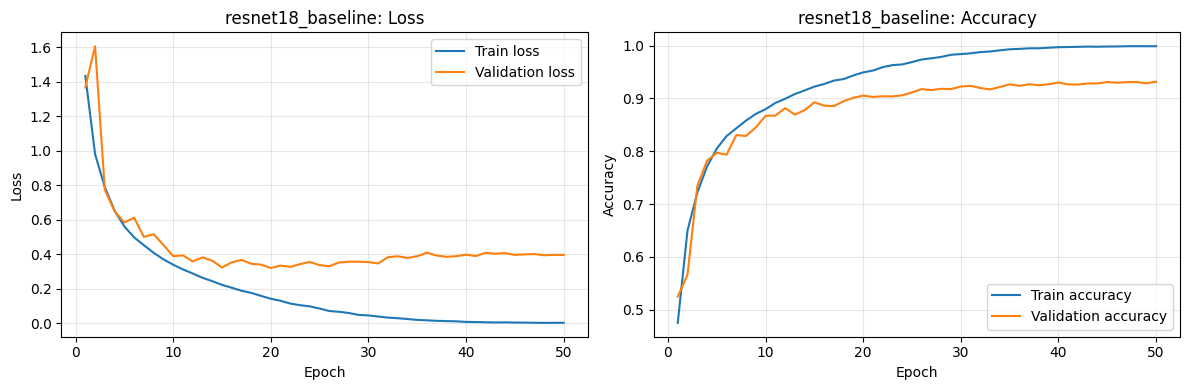

Saved: /content/drive/MyDrive/ECGR4106_HW1/problem3/figures/resnet18_baseline_curves.png


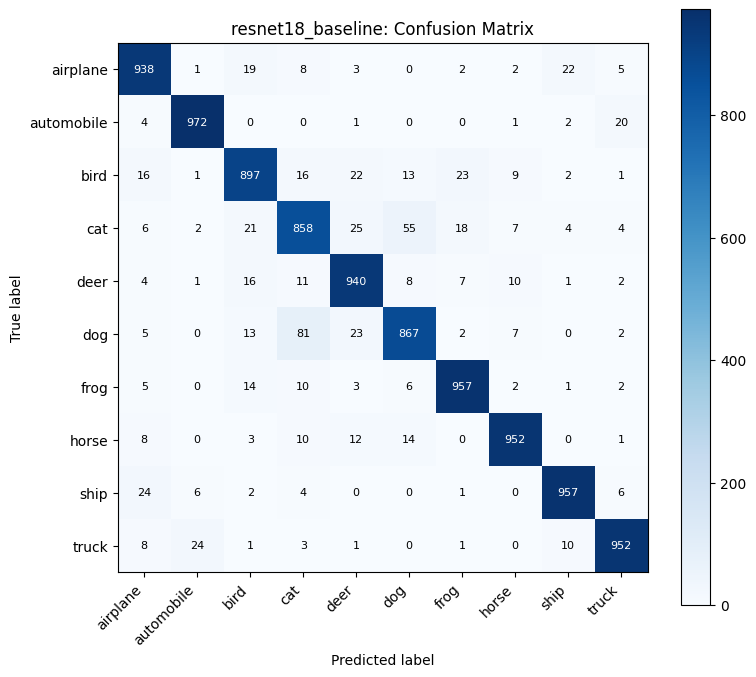

Saved: /content/drive/MyDrive/ECGR4106_HW1/problem3/figures/resnet18_baseline_confusion_matrix.png


In [ ]:
plot_history(hist_r18_base, "resnet18_baseline")
plot_confusion_matrix(test_r18_base["labels"], test_r18_base["preds"], "resnet18_baseline")

### Train ResNet-11 with Dropout p = 0.3

This cell applies dropout after global average pooling in ResNet-11 and trains with p = 0.3.


In [ ]:
resnet11_dropout_03 = ResNet11(num_classes=num_classes, dropout_p=0.3)
resnet11_dropout_03, hist_r11_d03, test_r11_d03, summary_r11_d03 = train_model(
    resnet11_dropout_03,
    run_name="resnet11_dropout_03",
    epochs=resnet_epochs,
    lr=learning_rate,
)
summary_r11_d03

resnet11_dropout_03 | epoch 01/50 | train loss 1.4745 | train acc 0.4596 | val loss 1.2536 | val acc 0.5512 | 30.9s
resnet11_dropout_03 | epoch 02/50 | train loss 1.0198 | train acc 0.6354 | val loss 0.9650 | val acc 0.6596 | 30.7s
resnet11_dropout_03 | epoch 03/50 | train loss 0.8223 | train acc 0.7116 | val loss 0.8130 | val acc 0.7110 | 32.4s
resnet11_dropout_03 | epoch 04/50 | train loss 0.7032 | train acc 0.7537 | val loss 0.7604 | val acc 0.7382 | 31.3s
resnet11_dropout_03 | epoch 05/50 | train loss 0.6094 | train acc 0.7901 | val loss 0.6088 | val acc 0.7892 | 30.6s
resnet11_dropout_03 | epoch 06/50 | train loss 0.5486 | train acc 0.8096 | val loss 0.5818 | val acc 0.7998 | 31.4s
resnet11_dropout_03 | epoch 07/50 | train loss 0.4984 | train acc 0.8274 | val loss 0.5745 | val acc 0.8060 | 31.4s
resnet11_dropout_03 | epoch 08/50 | train loss 0.4526 | train acc 0.8429 | val loss 0.5186 | val acc 0.8290 | 31.4s
resnet11_dropout_03 | epoch 09/50 | train loss 0.4146 | train acc 0.8564

{'run_name': 'resnet11_dropout_03',
 'epochs': 50,
 'learning_rate': 0.001,
 'optimizer': 'Adam',
 'scheduler': 'CosineAnnealingLR',
 'batch_size': 128,
 'seed': 42,
 'parameter_count': 9623882,
 'best_val_accuracy': 0.9204,
 'test_loss': 0.41518782482147215,
 'final_test_accuracy': 0.9203,
 'total_training_time_sec': 1545.4802057743073,
 'mean_epoch_time_sec': 30.842782540321352}

### Train ResNet-11 with Dropout p = 0.5

This cell applies stronger dropout after global average pooling in ResNet-11 and trains with p = 0.5.


In [ ]:
resnet11_dropout_05 = ResNet11(num_classes=num_classes, dropout_p=0.5)
resnet11_dropout_05, hist_r11_d05, test_r11_d05, summary_r11_d05 = train_model(
    resnet11_dropout_05,
    run_name="resnet11_dropout_05",
    epochs=resnet_epochs,
    lr=learning_rate,
)
summary_r11_d05

resnet11_dropout_05 | epoch 01/50 | train loss 1.5071 | train acc 0.4465 | val loss 1.1624 | val acc 0.5824 | 30.5s
resnet11_dropout_05 | epoch 02/50 | train loss 1.0352 | train acc 0.6313 | val loss 1.3342 | val acc 0.5636 | 30.6s
resnet11_dropout_05 | epoch 03/50 | train loss 0.8552 | train acc 0.6998 | val loss 0.9171 | val acc 0.6950 | 31.5s
resnet11_dropout_05 | epoch 04/50 | train loss 0.7140 | train acc 0.7534 | val loss 0.7167 | val acc 0.7536 | 31.5s
resnet11_dropout_05 | epoch 05/50 | train loss 0.6227 | train acc 0.7839 | val loss 0.8173 | val acc 0.7430 | 31.1s
resnet11_dropout_05 | epoch 06/50 | train loss 0.5574 | train acc 0.8094 | val loss 0.5148 | val acc 0.8188 | 30.3s
resnet11_dropout_05 | epoch 07/50 | train loss 0.5054 | train acc 0.8259 | val loss 0.5299 | val acc 0.8188 | 30.2s
resnet11_dropout_05 | epoch 08/50 | train loss 0.4615 | train acc 0.8426 | val loss 0.4883 | val acc 0.8378 | 30.6s
resnet11_dropout_05 | epoch 09/50 | train loss 0.4252 | train acc 0.8539

{'run_name': 'resnet11_dropout_05',
 'epochs': 50,
 'learning_rate': 0.001,
 'optimizer': 'Adam',
 'scheduler': 'CosineAnnealingLR',
 'batch_size': 128,
 'seed': 42,
 'parameter_count': 9623882,
 'best_val_accuracy': 0.9268,
 'test_loss': 0.40846715784072873,
 'final_test_accuracy': 0.9203,
 'total_training_time_sec': 1536.1104872226715,
 'mean_epoch_time_sec': 30.66790063858032}

### Train ResNet-18 with Dropout p = 0.3

This cell applies dropout p = 0.3 after global average pooling in ResNet-18.


In [ ]:
resnet18_dropout_03 = ResNet18(num_classes=num_classes, dropout_p=0.3)
resnet18_dropout_03, hist_r18_d03, test_r18_d03, summary_r18_d03 = train_model(
    resnet18_dropout_03,
    run_name="resnet18_dropout_03",
    epochs=resnet_epochs,
    lr=learning_rate,
)
summary_r18_d03

resnet18_dropout_03 | epoch 01/50 | train loss 1.5350 | train acc 0.4338 | val loss 1.3194 | val acc 0.5626 | 42.6s
resnet18_dropout_03 | epoch 02/50 | train loss 1.0410 | train acc 0.6272 | val loss 1.0590 | val acc 0.6392 | 42.4s
resnet18_dropout_03 | epoch 03/50 | train loss 0.8026 | train acc 0.7197 | val loss 0.8333 | val acc 0.7316 | 43.1s
resnet18_dropout_03 | epoch 04/50 | train loss 0.6652 | train acc 0.7693 | val loss 0.8583 | val acc 0.7292 | 42.8s
resnet18_dropout_03 | epoch 05/50 | train loss 0.5745 | train acc 0.8004 | val loss 0.5976 | val acc 0.7962 | 42.0s
resnet18_dropout_03 | epoch 06/50 | train loss 0.5068 | train acc 0.8246 | val loss 0.5854 | val acc 0.8002 | 42.0s
resnet18_dropout_03 | epoch 07/50 | train loss 0.4541 | train acc 0.8466 | val loss 0.4958 | val acc 0.8314 | 41.8s
resnet18_dropout_03 | epoch 08/50 | train loss 0.4144 | train acc 0.8567 | val loss 0.4477 | val acc 0.8518 | 41.9s
resnet18_dropout_03 | epoch 09/50 | train loss 0.3771 | train acc 0.8704

{'run_name': 'resnet18_dropout_03',
 'epochs': 50,
 'learning_rate': 0.001,
 'optimizer': 'Adam',
 'scheduler': 'CosineAnnealingLR',
 'batch_size': 128,
 'seed': 42,
 'parameter_count': 11173962,
 'best_val_accuracy': 0.9336,
 'test_loss': 0.40659387102127076,
 'final_test_accuracy': 0.9243,
 'total_training_time_sec': 2112.653923034668,
 'mean_epoch_time_sec': 42.18648732185364}

### Train ResNet-18 with Dropout p = 0.5

This cell applies dropout p = 0.5 after global average pooling in ResNet-18.


In [ ]:
resnet18_dropout_05 = ResNet18(num_classes=num_classes, dropout_p=0.5)
resnet18_dropout_05, hist_r18_d05, test_r18_d05, summary_r18_d05 = train_model(
    resnet18_dropout_05,
    run_name="resnet18_dropout_05",
    epochs=resnet_epochs,
    lr=learning_rate,
)
summary_r18_d05

resnet18_dropout_05 | epoch 01/50 | train loss 1.5555 | train acc 0.4246 | val loss 1.2124 | val acc 0.5626 | 42.2s
resnet18_dropout_05 | epoch 02/50 | train loss 1.0610 | train acc 0.6209 | val loss 1.0690 | val acc 0.6420 | 42.6s
resnet18_dropout_05 | epoch 03/50 | train loss 0.8597 | train acc 0.6970 | val loss 0.8241 | val acc 0.7230 | 42.7s
resnet18_dropout_05 | epoch 04/50 | train loss 0.7302 | train acc 0.7464 | val loss 0.8178 | val acc 0.7316 | 42.0s
resnet18_dropout_05 | epoch 05/50 | train loss 0.6248 | train acc 0.7838 | val loss 0.6618 | val acc 0.7732 | 42.1s
resnet18_dropout_05 | epoch 06/50 | train loss 0.5513 | train acc 0.8116 | val loss 0.5352 | val acc 0.8162 | 41.7s
resnet18_dropout_05 | epoch 07/50 | train loss 0.4940 | train acc 0.8299 | val loss 0.6374 | val acc 0.7938 | 41.8s
resnet18_dropout_05 | epoch 08/50 | train loss 0.4488 | train acc 0.8478 | val loss 0.5113 | val acc 0.8278 | 41.8s
resnet18_dropout_05 | epoch 09/50 | train loss 0.4114 | train acc 0.8590

{'run_name': 'resnet18_dropout_05',
 'epochs': 50,
 'learning_rate': 0.001,
 'optimizer': 'Adam',
 'scheduler': 'CosineAnnealingLR',
 'batch_size': 128,
 'seed': 42,
 'parameter_count': 11173962,
 'best_val_accuracy': 0.9294,
 'test_loss': 0.4297991084098816,
 'final_test_accuracy': 0.9231,
 'total_training_time_sec': 2106.339338541031,
 'mean_epoch_time_sec': 42.054004755020145}

### Plot ResNet Dropout Confusion Matrices

This cell plots confusion matrices for the dropout ResNet runs. These matrices show which CIFAR-10 classes are most often confused.


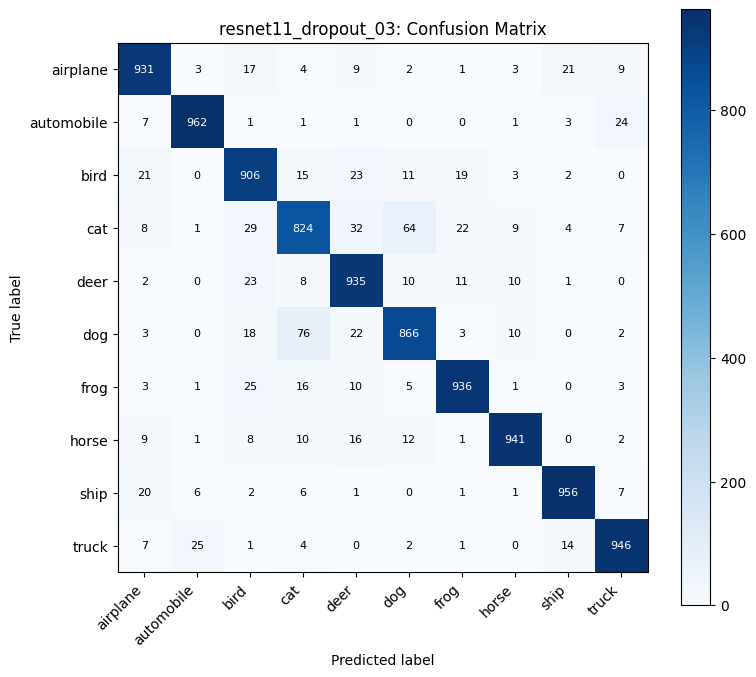

Saved: /content/drive/MyDrive/ECGR4106_HW1/problem3/figures/resnet11_dropout_03_confusion_matrix.png


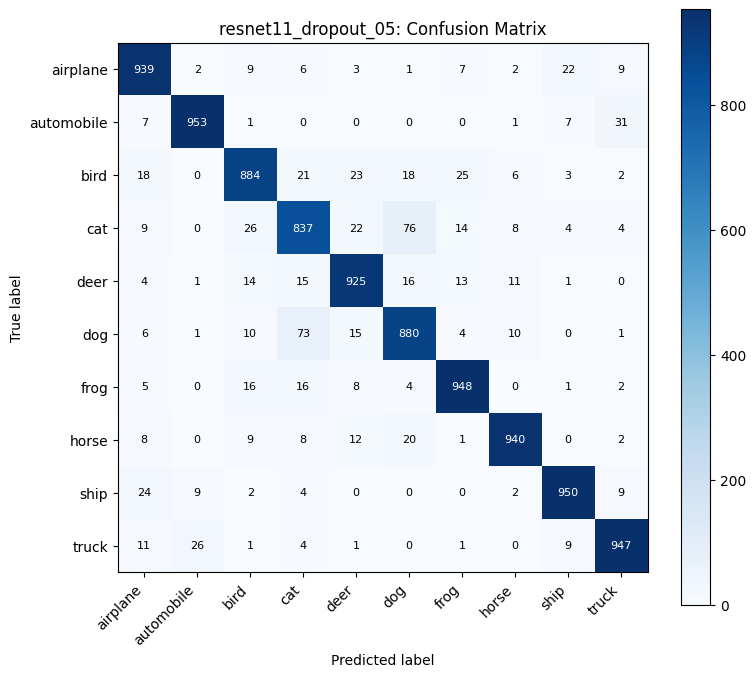

Saved: /content/drive/MyDrive/ECGR4106_HW1/problem3/figures/resnet11_dropout_05_confusion_matrix.png


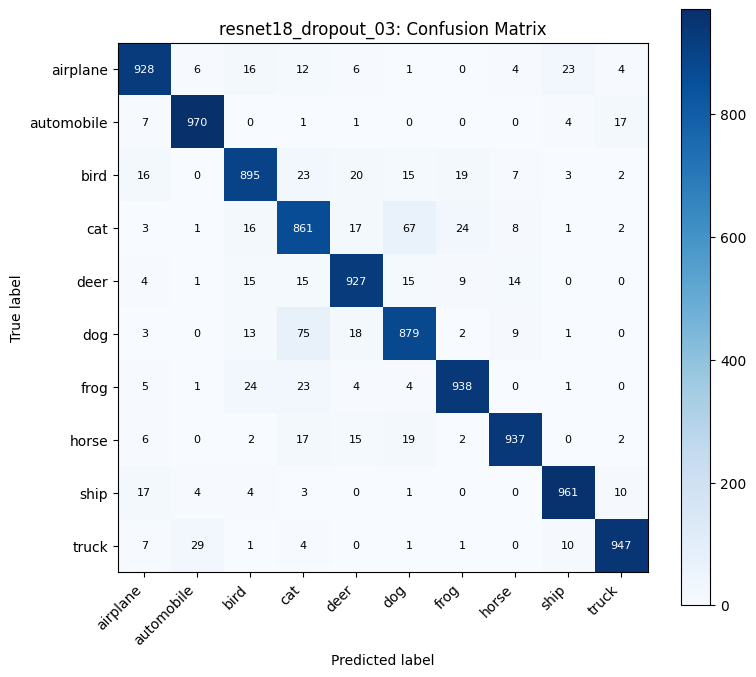

Saved: /content/drive/MyDrive/ECGR4106_HW1/problem3/figures/resnet18_dropout_03_confusion_matrix.png


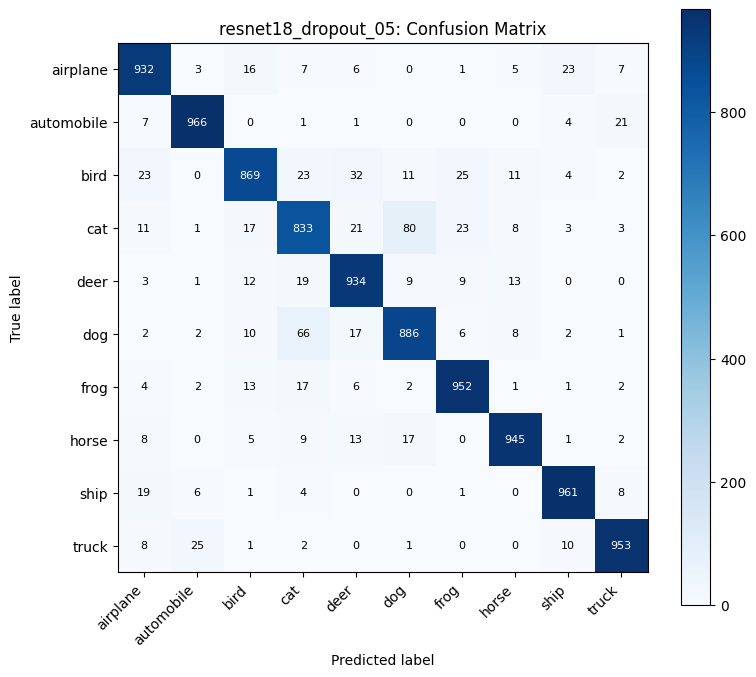

Saved: /content/drive/MyDrive/ECGR4106_HW1/problem3/figures/resnet18_dropout_05_confusion_matrix.png


In [ ]:
plot_confusion_matrix(test_r11_d03["labels"], test_r11_d03["preds"], "resnet11_dropout_03")
plot_confusion_matrix(test_r11_d05["labels"], test_r11_d05["preds"], "resnet11_dropout_05")
plot_confusion_matrix(test_r18_d03["labels"], test_r18_d03["preds"], "resnet18_dropout_03")
plot_confusion_matrix(test_r18_d05["labels"], test_r18_d05["preds"], "resnet18_dropout_05")

### Build ResNet Results Table

This cell combines all ResNet summaries into a single table with parameter count, validation accuracy, test accuracy, and training time.


In [ ]:
resnet_results_df = pd.DataFrame([
    summary_r11_base,
    summary_r11_d03,
    summary_r11_d05,
    summary_r18_base,
    summary_r18_d03,
    summary_r18_d05,
])
resnet_results_df["model_family"] = [
    "ResNet-11", "ResNet-11", "ResNet-11",
    "ResNet-18", "ResNet-18", "ResNet-18",
]
resnet_results_df["dropout"] = ["none", "0.3", "0.5", "none", "0.3", "0.5"]
resnet_results_df = resnet_results_df[[
    "run_name",
    "model_family",
    "dropout",
    "parameter_count",
    "best_val_accuracy",
    "final_test_accuracy",
    "mean_epoch_time_sec",
    "total_training_time_sec",
    "optimizer",
    "learning_rate",
    "scheduler",
    "batch_size",
    "seed",
]]
resnet_results_df.to_csv(OUTPUT_DIR / "problem3_resnet_results.csv", index=False)
resnet_results_df

,run_name,model_family,dropout,parameter_count,best_val_accuracy,final_test_accuracy,mean_epoch_time_sec,total_training_time_sec,optimizer,learning_rate,scheduler,batch_size,seed
0,resnet11_baseline,ResNet-11,none,9623882,0.9260,0.9196,30.639828,1534.973168,Adam,0.001,CosineAnnealingLR,128,42
1,resnet11_dropout_03,ResNet-11,0.3,9623882,0.9204,0.9203,30.842783,1545.480206,Adam,0.001,CosineAnnealingLR,128,42
2,resnet11_dropout_05,ResNet-11,0.5,9623882,0.9268,0.9203,30.667901,1536.110487,Adam,0.001,CosineAnnealingLR,128,42
3,resnet18_baseline,ResNet-18,none,11173962,0.9318,0.9290,42.104432,2108.653538,Adam,0.001,CosineAnnealingLR,128,42
4,resnet18_dropout_03,ResNet-18,0.3,11173962,0.9336,0.9243,42.186487,2112.653923,Adam,0.001,CosineAnnealingLR,128,42
5,resnet18_dropout_05,ResNet-18,0.5,11173962,0.9294,0.9231,42.054005,2106.339339,Adam,0.001,CosineAnnealingLR,128,42


### Compare ResNet Training Histories

This cell plots validation accuracy comparisons for ResNet-11 versus ResNet-18 and for each dropout setting.


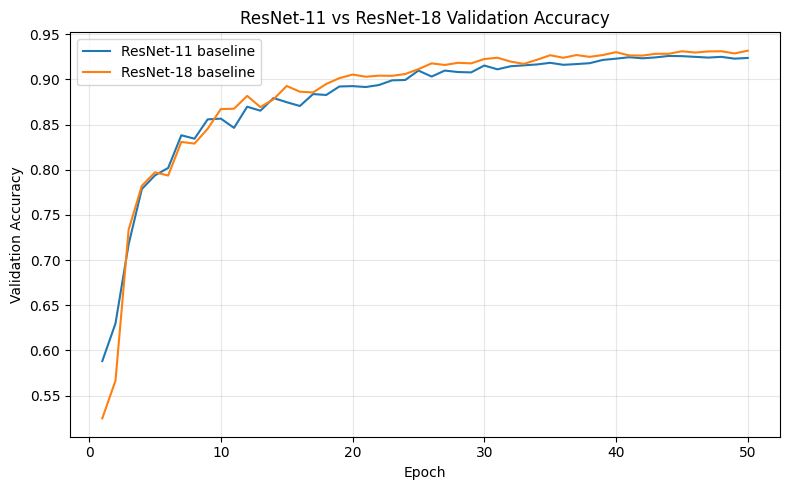

Saved: /content/drive/MyDrive/ECGR4106_HW1/problem3/figures/resnet11_vs_resnet18_val_accuracy.png


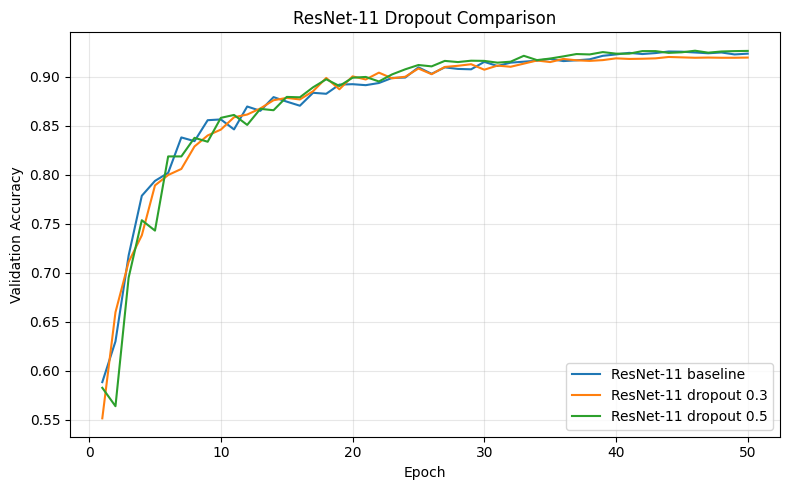

Saved: /content/drive/MyDrive/ECGR4106_HW1/problem3/figures/resnet11_dropout_val_accuracy.png


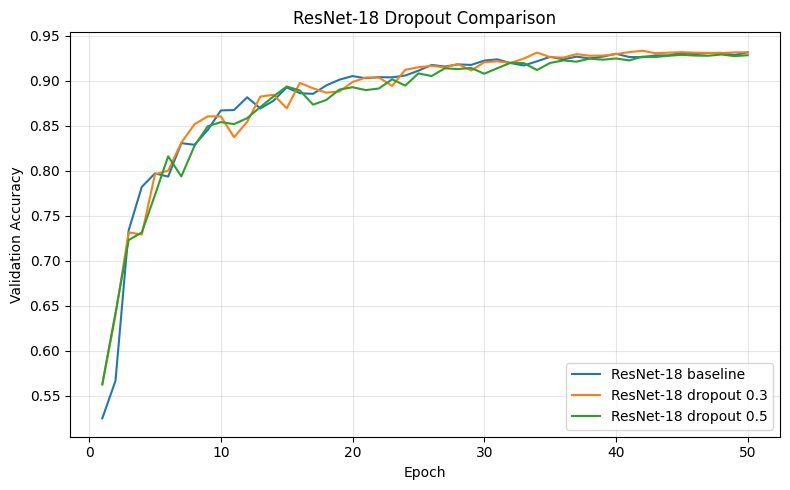

Saved: /content/drive/MyDrive/ECGR4106_HW1/problem3/figures/resnet18_dropout_val_accuracy.png


In [ ]:
compare_histories(
    {
        "ResNet-11 baseline": hist_r11_base,
        "ResNet-18 baseline": hist_r18_base,
    },
    "val_accuracy",
    "ResNet-11 vs ResNet-18 Validation Accuracy",
    "Validation Accuracy",
    "resnet11_vs_resnet18_val_accuracy.png",
)

compare_histories(
    {
        "ResNet-11 baseline": hist_r11_base,
        "ResNet-11 dropout 0.3": hist_r11_d03,
        "ResNet-11 dropout 0.5": hist_r11_d05,
    },
    "val_accuracy",
    "ResNet-11 Dropout Comparison",
    "Validation Accuracy",
    "resnet11_dropout_val_accuracy.png",
)

compare_histories(
    {
        "ResNet-18 baseline": hist_r18_base,
        "ResNet-18 dropout 0.3": hist_r18_d03,
        "ResNet-18 dropout 0.5": hist_r18_d05,
    },
    "val_accuracy",
    "ResNet-18 Dropout Comparison",
    "Validation Accuracy",
    "resnet18_dropout_val_accuracy.png",
)

### ResNet Test Accuracy Bar Chart

This cell creates a bar chart comparing final test accuracy across all ResNet variants.


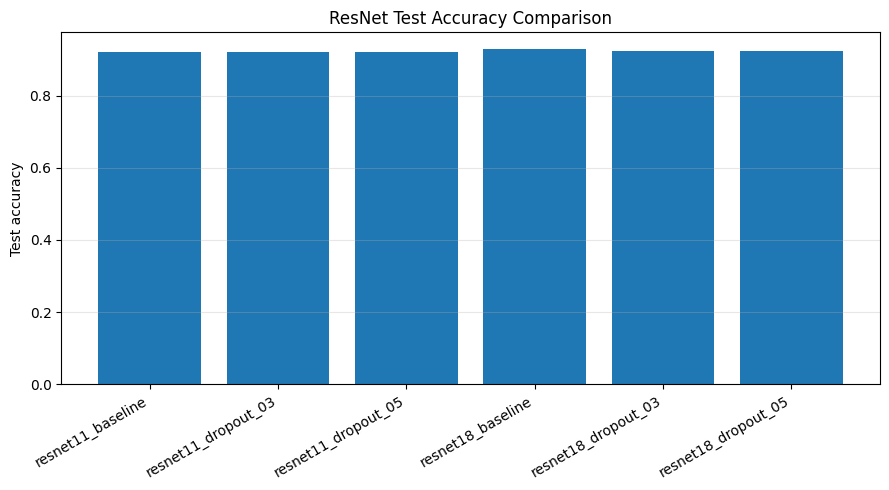

Saved: /content/drive/MyDrive/ECGR4106_HW1/problem3/figures/resnet_test_accuracy_bar_chart.png


In [ ]:
plt.figure(figsize=(9, 5))
plt.bar(resnet_results_df["run_name"], resnet_results_df["final_test_accuracy"])
plt.ylabel("Test accuracy")
plt.title("ResNet Test Accuracy Comparison")
plt.xticks(rotation=30, ha="right")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
save_path = FIG_DIR / "resnet_test_accuracy_bar_chart.png"
plt.savefig(save_path, dpi=200, bbox_inches="tight")
plt.show()
print("Saved:", save_path)

### Final Homework Comparison Table

This cell combines the best AlexNet, best VGG, best ResNet-11, and best ResNet-18 results into the final homework comparison table.


In [ ]:
# Replace these values after you finish all runs.
best_alexnet = {
    "model": "Best AlexNet",
    "parameter_count": 4_483_146,
    "final_test_accuracy": 0.8477,
    "mean_epoch_time_sec": 27.52,
}

best_vgg = {
    "model": "Best VGG",
    "parameter_count": None,          # fill from problem-2 results
    "final_test_accuracy": None,      # fill from problem-2 results
    "mean_epoch_time_sec": None,      # fill from problem-2 results
}

best_r11 = resnet_results_df[resnet_results_df["model_family"] == "ResNet-11"].sort_values("final_test_accuracy", ascending=False).iloc[0]
best_r18 = resnet_results_df[resnet_results_df["model_family"] == "ResNet-18"].sort_values("final_test_accuracy", ascending=False).iloc[0]

final_rows = [
    best_alexnet,
    best_vgg,
    {
        "model": "Best ResNet-11",
        "parameter_count": int(best_r11["parameter_count"]),
        "final_test_accuracy": float(best_r11["final_test_accuracy"]),
        "mean_epoch_time_sec": float(best_r11["mean_epoch_time_sec"]),
    },
    {
        "model": "Best ResNet-18",
        "parameter_count": int(best_r18["parameter_count"]),
        "final_test_accuracy": float(best_r18["final_test_accuracy"]),
        "mean_epoch_time_sec": float(best_r18["mean_epoch_time_sec"]),
    },
]

final_comparison_df = pd.DataFrame(final_rows)
final_comparison_df.to_csv(OUTPUT_DIR / "homework1_final_model_comparison.csv", index=False)
final_comparison_df

,model,parameter_count,final_test_accuracy,mean_epoch_time_sec
0,Best AlexNet,4483146.0,0.8477,27.520000
1,Best VGG,NaN,NaN,NaN
2,Best ResNet-11,9623882.0,0.9203,30.842783
3,Best ResNet-18,11173962.0,0.9290,42.104432


### Final Homework Accuracy Bar Chart

This cell plots the final test accuracy comparison across the best architecture from each model family.


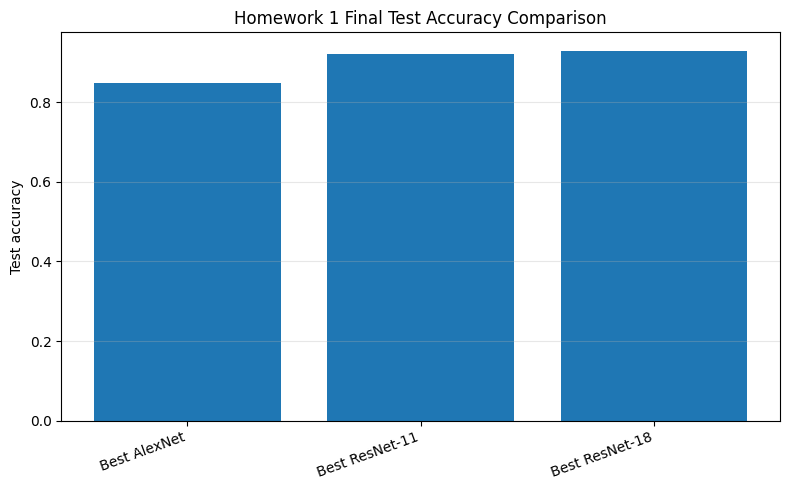

Saved: /content/drive/MyDrive/ECGR4106_HW1/problem3/figures/homework1_final_test_accuracy_bar_chart.png


In [ ]:
plot_df = final_comparison_df.dropna(subset=["final_test_accuracy"])

plt.figure(figsize=(8, 5))
plt.bar(plot_df["model"], plot_df["final_test_accuracy"])
plt.ylabel("Test accuracy")
plt.title("Homework 1 Final Test Accuracy Comparison")
plt.xticks(rotation=20, ha="right")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
save_path = FIG_DIR / "homework1_final_test_accuracy_bar_chart.png"
plt.savefig(save_path, dpi=200, bbox_inches="tight")
plt.show()
print("Saved:", save_path)